# $r^2$ Evaporation Law

Integration of the conservation equations for mass and vapour mass fractions from the droplet surface to deep into the gas phase region gives an expression for the droplet vapourisation rate:

$$
\dot{m} = 4 \pi r_d \rho_g D  \ln \left(1+B_M\right)
$$

$$
B_M = \frac{Y_{\infty}-Y_s}{Y_s-1}
$$

Where
$\rho_g$ is the density of the gas phase,
$D$ is the mass diffusivity of the vapour in the gas phase,
$r_d$ the radius of the droplet,
$Y_{\infty}$ the vapour mass fraction far away from the droplet's surface and
$Y_s$ the vapour mass fraction at the droplet surface.

For a droplet with constant density over time, the rate of change of the droplet's radius can be expressed in terms of the vapourisation rate:

$$
\dot{m} = 4 \pi r_d^2 \frac{dr_d}{dt} \rho_d
$$

Where
$\rho_g$ is the density of the droplet.

In [92]:
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from Common.geometry import mass_to_radius, radius_to_mass
from Common.water import saturation_vapour_pressure, vapour_mass_fraction_from_vapour_pressure, wet_bulb_temperature

def vapourisation_rate(droplet_radius:float|np.ndarray,
                       surface_vapour_mass_fraction:float=0.1,
                       far_vapour_mass_fraction:float=0.0,
                       gas_density:float=1.225,
                       mass_diffusivity:float=0.242e-4)->float|np.ndarray:
    Spalding = (far_vapour_mass_fraction-surface_vapour_mass_fraction)/(surface_vapour_mass_fraction-1)
    return 4*np.pi*droplet_radius*gas_density*mass_diffusivity*np.log(1+Spalding)

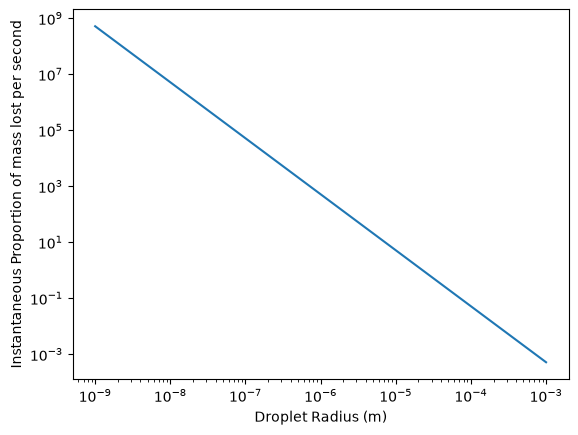

In [93]:
import matplotlib.pyplot as plt

temperature = 293 #K
rh = 0.0
droplet_density = 1000.0

droplet_radii = np.logspace(-9,-3,100)
droplet_masses = radius_to_mass(droplet_radii,droplet_density)

droplet_temperature = wet_bulb_temperature(temperature, rh)
far_vapour_mass_fraction = vapour_mass_fraction_from_vapour_pressure(saturation_vapour_pressure(temperature)) * rh
surface_vapour_mass_fraction = vapour_mass_fraction_from_vapour_pressure(
    saturation_vapour_pressure(droplet_temperature))
vapourisation_rates = vapourisation_rate(droplet_radii,surface_vapour_mass_fraction,far_vapour_mass_fraction)

plt.plot(droplet_radii,vapourisation_rates/droplet_masses)
plt.ylabel("Instantaneous Proportion of mass lost per second")
plt.xlabel("Droplet Radius (m)")
plt.xscale("log")
plt.yscale("log")
plt.show()

# Numerically Solving Vapourisation

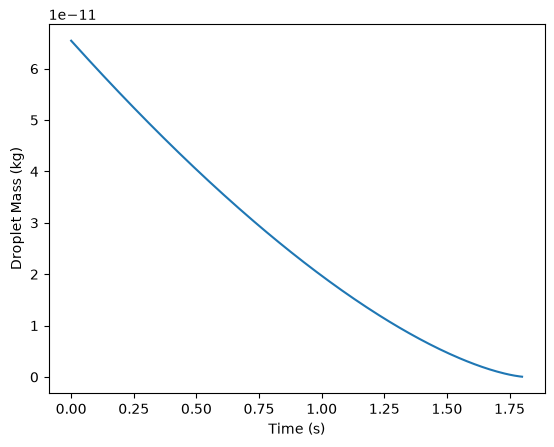

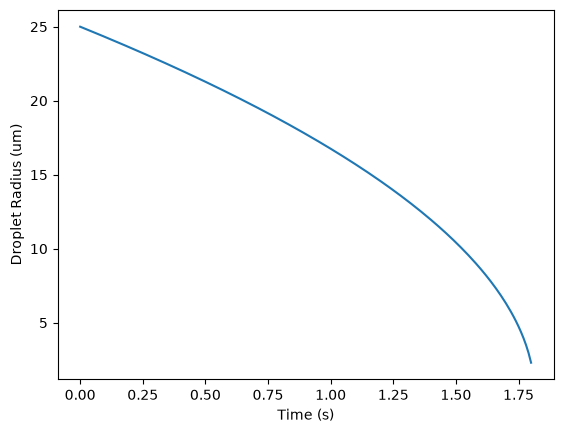

In [94]:
from scipy.integrate import solve_ivp

initial_droplet_radius = 25e-6
initial_droplet_mass = 4/3 * np.pi * initial_droplet_radius**3 * droplet_density

def derivative(time:float, mass:np.ndarray)->np.ndarray:
    radius = mass_to_radius(mass,droplet_density)
    return -vapourisation_rate(radius,surface_vapour_mass_fraction,far_vapour_mass_fraction)

solutions = solve_ivp(derivative,(0,1.8),np.array([initial_droplet_mass]),method="Radau",max_step=0.01)

masses = solutions.y[0]
plt.plot(solutions.t,masses)
plt.ylabel("Droplet Mass (kg)")
plt.xlabel("Time (s)")
plt.show()

radii = np.cbrt(3*masses/(4*np.pi*droplet_density))
plt.plot(solutions.t,radii*1e6)
plt.ylabel("Droplet Radius (um)")
plt.xlabel("Time (s)")
plt.show()

After equating the above, the expression can be expressed in terms of the droplet radius and its derivative:

$$
r_d \frac{dr_d}{dt} = \frac{\rho_g D \ln \left(1+B_M\right)}{\rho_d}
$$

By the chain rule, the left hand side is equal to half the rate of change of the radius squared. Under constant gas phase conditions, this derivative is also constant. This means that a measurement of an evaporating droplet's square radius will be linear in constant conditions (ignoring initial evaporative cooling). The rate of change of the square droplet diameter is normally referred to as the evaporation rate $\kappa$:

$$
\frac{dr_d^2}{dt} = \frac{2\rho_g D \ln \left(1+B_M\right)}{\rho_d}
$$

Knowing the initial droplet radius, you can then determine the droplet lifetime using $\kappa$.

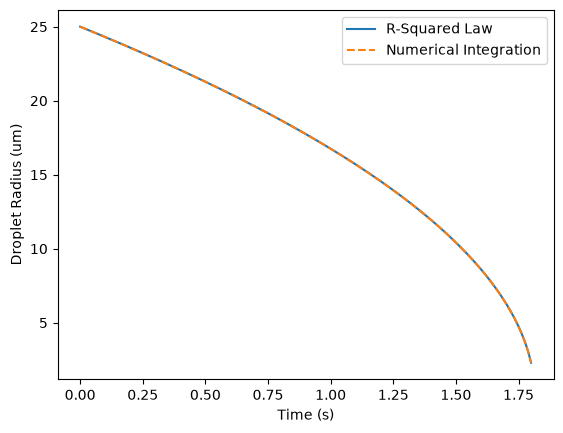

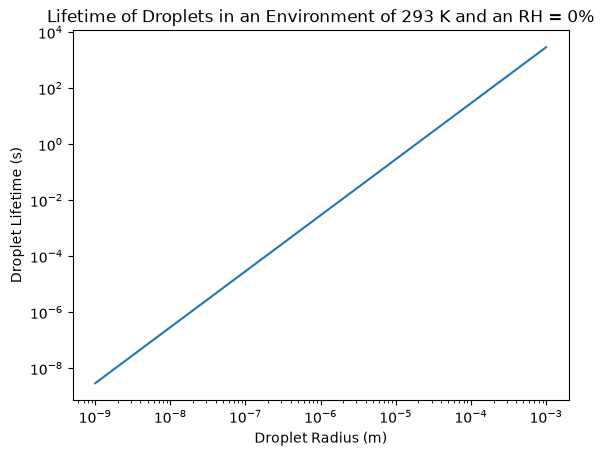

In [95]:
def evaporation_rate(surface_vapour_mass_fraction:float=0.1,
                       far_vapour_mass_fraction:float=0.0,
                       gas_density:float=1.225,
                       mass_diffusivity:float=0.242e-4)->float|np.ndarray:
    Spalding = (far_vapour_mass_fraction-surface_vapour_mass_fraction)/(surface_vapour_mass_fraction-1)
    return 2*gas_density * mass_diffusivity*np.log(1+Spalding) / droplet_density

kappa = evaporation_rate(surface_vapour_mass_fraction,far_vapour_mass_fraction)
radii = np.sqrt(initial_droplet_radius**2 - kappa*solutions.t)
plt.plot(solutions.t,radii*1e6,label="R-Squared Law")

radii_integrated = np.cbrt(3*masses/(4*np.pi*droplet_density))
plt.plot(solutions.t,radii*1e6,linestyle="--",label="Numerical Integration")
plt.ylabel("Droplet Radius (um)")
plt.xlabel("Time (s)")

plt.legend()
plt.show()

lifetimes = droplet_radii**2/kappa
plt.plot(droplet_radii,lifetimes)
plt.xscale("log")
plt.yscale("log")
plt.title(f"Lifetime of Droplets in an Environment of {temperature} K and an RH = {rh*100:.0f}%")
plt.ylabel("Droplet Lifetime (s)")
plt.xlabel("Droplet Radius (m)")
plt.show()